# Оптимизация конверсии через A/B-тестирование

# Описание

Датасет **BassBurst** содержит более **30 000 сессий** посетителей лендинга интернет-магазина аудиотехники (колонки BassBurst). Данные собраны для анализа **A/B-тестов** и **оптимизации конверсии**. Лендинг тестировался в **трёх вариантах дизайна: Vibrant, Cold, Heat**.

## Цель

Спроектировать и проанализировать A/B-эксперимент: от выбора основной метрики и расчёта размера выборки до проверки гипотез, интерпретации результатов и формулировки продуктовой рекомендации.

## Структура данных

- **user_id** — уникальный идентификатор посетителя.
- **session_id** — уникальный идентификатор сессии (визита).
- **sign_in** — способ входа: через email или гостевой доступ.
- **name** — имя посетителя (сгенерировано, может быть из разных локалей).
- **demographic_age** — возраст посетителя (от 14 до 80 лет).
- **demographic_age_group** — возрастная группа: «Teenage», «Adult», «Old».
- **demographic_gender** — пол: Male, Female, Not Answered.
- **email** — email пользователя (если вход был через email).
- **location** — город, из которого зашёл посетитель.
- **country** — страна, соответствующая городу.
- **device_type** — тип устройства: Mobile, Desktop, Tablet.
- **timestamp** — время начала сессии.
- **variant_group** — вариант дизайна лендинга: Vibrant, Cold, Heat.
- **time_spent** — общее время (в минутах), проведённое на лендинге.
- **pages_visited** — количество просмотренных страниц за сессию.
- **conversion_flag** — бинарный флаг: 1 — конверсия (регистрация или покупка), 0 — нет.
- **conversion_type** — тип конверсии: Signup или Purchase.
- **traffic_source** — источник трафика: Organic, Paid, Social, Referral.
- **product_purchased** — список купленных товаров (если была покупка).
- **revenue** — выручка от транзакции (если была покупка).
- **payment_type** — способ оплаты: Card или COD (cash on delivery).
- **card_type** — тип карты при оплате картой: Amex, Visa, Master.
- **coupon_applied** - был ли использован купон (Да/Нет).
- **bounce_flag** - указывает, была ли сессия неудачной (просмотрена только одна страница):
  - 1 — да, сессия отказная: пользователь просмотрел только одну страницу.
  - 0 — нет, сессия не отказная: пользователь просмотрел две или более страницы.


## План работы

### 1. Загрузка и знакомство с данными
- Импортировать необходимые библиотеки.
- Загрузить датасет.
- Знакомство с данными `df.info()` и `df.describe()`.
- Проверить уникальные значения в категориальных колонках.
- Проверить баланс групп и baseline-конверсию по вариантам дизайна.

### 2. Предобработка данных
- Приведение названий колонок к `snake_case`(по необходимости).
- Обработка пропусков.
- Проверка на дубликаты (полные и по `session_id`).
- Проверка аномалий в `time_spent`, `pages_visited`, `revenue`.

### 3. Дизайн эксперимента
- Выбор основной и вспомогательных метрик.
- Расчёт размера выборки (`n`) под заданный MDE.
- Оценка MDE, который детектируется при текущем объёме данных.

### 4. Исследовательский анализ (EDA)
- Распределения числовых метрик по группам (гистограммы, boxplot).
- Конверсия по группам (столбчатая диаграмма + доверительные интервалы).
- Проверка баланса групп — SRM (Sample Ratio Mismatch).
- Проверка нормальности непрерывных метрик.

### 5. Проверка гипотез

**Гипотеза 1: Различие конверсии между вариантами дизайна**  
- H₀: конверсия не различается между `Vibrant`, `Cold`, `Heat`.  
- H₁: хотя бы один вариант отличается.  
- Метод: Хи-квадрат + попарные сравнения с поправкой на множественные сравнения.

**Гипотеза 2: Различие времени на лендинге между вариантами**  
- H₀: `time_spent` не различается между группами.  
- H₁: `time_spent` различается хотя бы между двумя группами.  
- Метод: ANOVA + Tukey HSD (попарные сравнения).

**Гипотеза 3: Различие выручки между вариантами**  
- H₀: `revenue` не различается между группами (среди конвертировавших).  
- H₁: `revenue` различается.  
- Метод: Bootstrap-доверительный интервал для разницы средних.

### 6. Выводы
- Какой вариант показал лучшую конверсию.
- Статистическая и практическая значимость результата.
- Продуктовая рекомендация.
- Ограничения исследования.

# Загрузка и знакомство с данными

## Импорт библиотек

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Для расчёта размера выборки и MDE («Дизайн эксперимента»)
from statsmodels.stats.power import NormalIndPower

# Для z-test пропорций и поправок на множественные сравнения («Проверка гипотез»)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

# Для Tukey HSD — попарных сравнений после ANOVA («Проверка гипотез»)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Для bootstrap-доверительного интервала («Проверка гипотез»)
from sklearn.utils import resample

# отображение всех колонок датасета
pd.set_option('display.max_columns', None)

## Загрузка датасета

In [26]:
df = pd.read_csv('cleaned_speakers_data.csv')

In [27]:
df.head()

,user_id,session_id,sign_in,name,demographic_age,demographic_age_group,demographic_gender,email,location,country,device_type,timestamp,variant_group,time_spent,pages_visited,conversion_flag,conversion_type,traffic_source,product_purchased,revenue_$,payment_type,card_type,coupon_applied,bounce_flag
0,U10477,S000001,Email,Victor Navarro-Noël,31,Adult,Female,victornavarronoël251@hotmail.com,Rome,Italy,Desktop,2025-01-18 21:30:04.168185,Heat,2.65,7,0,NCT,Organic,NPP,0.0,NPT,NCAT,ND,1
1,U01536,S000002,Email,王秀云,39,Adult,Female,王秀云617@gmail.com,Madrid,Spain,Mobile,2025-01-12 04:36:36.971286,Vibrant,9.53,5,0,NCT,Social,NPP,0.0,NPT,NCAT,ND,0
2,U00107,S000003,Guest,Ucchal Sabharwal,68,Old,Male,Not Provided,Manchester,UK,Mobile,2025-01-20 06:49:20.481864,Cold,2.94,7,0,NCT,Organic,NPP,0.0,NPT,NCAT,ND,0
3,U13886,S000004,Email,Virginie Schmitt,72,Old,Female,virginieschmitt827@gmail.com,Sydney,Australia,Mobile,2025-02-01 08:59:46.938408,Cold,16.76,10,0,NCT,Social,NPP,0.0,NPT,NCAT,ND,0
4,U05926,S000005,Email,Cynthia Drake,51,Adult,No Answer,cynthiadrake47@hotmail.com,Mumbai,India,Desktop,2025-02-16 16:02:00.285005,Cold,6.28,6,0,NCT,Organic,NPP,0.0,NPT,NCAT,ND,0


In [28]:
df.tail()

,user_id,session_id,sign_in,name,demographic_age,demographic_age_group,demographic_gender,email,location,country,device_type,timestamp,variant_group,time_spent,pages_visited,conversion_flag,conversion_type,traffic_source,product_purchased,revenue_$,payment_type,card_type,coupon_applied,bounce_flag
29995,U08032,S029996,Email,Radhika Gole,15,Teenage,Male,radhikagole401@outlook.com,Sydney,Australia,Desktop,2025-01-11 12:46:42.975880,Vibrant,17.43,1,1,Signup,Social,NPP,0.00,NPT,NCAT,ND,1
29996,U10440,S029997,Email,Aurélie Jacob,51,Adult,Female,auréliejacob443@protonmail.com,Hong Kong,Hong Kong,Mobile,2025-01-16 16:24:44.057877,Cold,17.28,4,0,NCT,Social,NPP,0.00,NPT,NCAT,ND,0
29997,U07125,S029998,Email,Rodney Miller,15,Teenage,Female,rodneymiller655@gmail.com,Tokyo,Japan,Tablet,2025-01-26 17:03:17.515872,Vibrant,9.88,2,0,NCT,Social,NPP,0.00,NPT,NCAT,ND,0
29998,U03820,S029999,Email,牛秀珍,73,Old,Female,牛秀珍771@gmail.com,Singapore,Singapore,Desktop,2025-02-15 14:03:56.734684,Cold,17.80,8,1,Purchase,Paid,Sony SRS-XB43,249.99,COD,NCAT,No,0
29999,U08963,S030000,Email,莫超,63,Adult,Male,莫超735@yahoo.com,Sydney,Australia,Mobile,2025-02-16 09:59:45.665965,Heat,5.52,3,0,NCT,Paid,NPP,0.00,NPT,NCAT,ND,0


## Знакомство с данными

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                30000 non-null  object 
 1   session_id             30000 non-null  object 
 2   sign_in                30000 non-null  object 
 3   name                   30000 non-null  object 
 4   demographic_age        30000 non-null  int64  
 5   demographic_age_group  30000 non-null  object 
 6   demographic_gender     30000 non-null  object 
 7   email                  30000 non-null  object 
 8   location               30000 non-null  object 
 9   country                30000 non-null  object 
 10  device_type            30000 non-null  object 
 11  timestamp              30000 non-null  object 
 12  variant_group          30000 non-null  object 
 13  time_spent             30000 non-null  float64
 14  pages_visited          30000 non-null  int64  
 15  co

**Вывод:**

Все колонки заполнены, типы адекватные (кроме timestamp — он object, его надо будет преобразовать в datetime на этапе предобработки)

In [30]:
df.describe()

,demographic_age,time_spent,pages_visited,conversion_flag,revenue_$,bounce_flag
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,46.905533,10.524185,5.501467,0.151167,26.208553,0.189067
std,19.405500,5.481363,2.874208,0.358217,137.294872,0.391568
min,14.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,5.780000,3.000000,0.000000,0.000000,0.000000
50%,47.000000,10.580000,5.000000,0.000000,0.000000,0.000000
75%,64.000000,15.270000,8.000000,0.000000,0.000000,0.000000
max,80.000000,20.000000,10.000000,1.000000,2499.000000,1.000000


## Уникальные значения в категориальных колонках

In [31]:
# Колонки с малым числом уникальных значений — смотрим распределение полностью
cat_cols_small = ['variant_group', 'sign_in', 'demographic_age_group',
                  'demographic_gender', 'device_type', 'conversion_type',
                  'traffic_source', 'payment_type', 'card_type']

for col in cat_cols_small:
    print(f'Колонка: {col}')
    print(f'Пропусков: {df[col].isna().sum()} ({df[col].isna().mean()*100:.1f}%)')
    print(f'Количество уникальных: {df[col].nunique()}')
    print(f'Распределение:\n{df[col].value_counts()}')
    print('-' * 40)

Колонка: variant_group
Пропусков: 0 (0.0%)
Количество уникальных: 3
Распределение:
variant_group
Vibrant    10046
Heat       10026
Cold        9928
Name: count, dtype: int64
----------------------------------------
Колонка: sign_in
Пропусков: 0 (0.0%)
Количество уникальных: 2
Распределение:
sign_in
Email    20975
Guest     9025
Name: count, dtype: int64
----------------------------------------
Колонка: demographic_age_group
Пропусков: 0 (0.0%)
Количество уникальных: 3
Распределение:
demographic_age_group
Adult      20139
Old         7156
Teenage     2705
Name: count, dtype: int64
----------------------------------------
Колонка: demographic_gender
Пропусков: 0 (0.0%)
Количество уникальных: 3
Распределение:
demographic_gender
Male         13606
Female       13487
No Answer     2907
Name: count, dtype: int64
----------------------------------------
Колонка: device_type
Пропусков: 0 (0.0%)
Количество уникальных: 3
Распределение:
device_type
Mobile     18008
Desktop     8953
Tablet      30

In [32]:
# Колонки с большим числом уникальных — смотрим только nunique()
cat_cols_big = ['name', 'email', 'location', 'country', 'product_purchased']

for col in cat_cols_big:
    print(f'Колонка: {col}')
    print(f'Пропусков: {df[col].isna().sum()} ({df[col].isna().mean()*100:.1f}%)')
    print(f'Количество уникальных: {df[col].nunique()}')
    print('-' * 40)

Колонка: name
Пропусков: 0 (0.0%)
Количество уникальных: 23706
----------------------------------------
Колонка: email
Пропусков: 0 (0.0%)
Количество уникальных: 20974
----------------------------------------
Колонка: location
Пропусков: 0 (0.0%)
Количество уникальных: 26
----------------------------------------
Колонка: country
Пропусков: 0 (0.0%)
Количество уникальных: 15
----------------------------------------
Колонка: product_purchased
Пропусков: 0 (0.0%)
Количество уникальных: 74
----------------------------------------


**Вывод:**

Пропуски в явном виде отсутствуют, но часть колонок использует текстовые заглушки:

Not Provided в email,

NCT в conversion_type,

NPP в product_purchased,

NPT в payment_type,

NCAT в card_type,

ND в coupon_applied.

Это значит, что пропуски структурные (не применимо к сессии) и их надо учитывать при анализе конкретных подмножеств.

## Баланс групп и baseline-конверсию по вариантам дизайна

In [33]:
# Баланс групп
df['variant_group'].value_counts()

,count
variant_group,
Vibrant,10046
Heat,10026
Cold,9928


In [34]:
# Базовая конверсия по группам
df.groupby('variant_group')['conversion_flag'].mean()

,conversion_flag
variant_group,
Cold,0.180802
Heat,0.151706
Vibrant,0.121342


**Вывод:**

Baseline-конверсия различается между группами существенно: Cold — 18.1%, Heat — 15.2%, Vibrant — 12.1%. Разница между Cold и Vibrant — 6%. Статистическую значимость проверим на шаге проверки гипотез.

# Предобработка данных

## Колонки в формате snake_case

In [35]:
df = df.rename(columns={'revenue_$': 'revenue'})

In [36]:
#df.columns

## Преобразование колонки timestamp в форматы даты

In [37]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## Обработка пропусков

Есть текстовые заглушки, которые играют роль пропусков:

- Not Provided в email

- NCT в conversion_type

- NPP в product_purchased

- NPT в payment_type

- NCAT в card_type

- ND в coupon_applied

Заменяем текстовые заглушки на NaN

In [38]:
# Явные NaN позволяют pandas корректно их учитывать в groupby, describe, isna() и т.д.

df['email'] = df['email'].replace('Not Provided', np.nan)
df['conversion_type'] = df['conversion_type'].replace('NCT', np.nan)
df['product_purchased'] = df['product_purchased'].replace('NPP', np.nan)
df['payment_type'] = df['payment_type'].replace('NPT', np.nan)
df['card_type'] = df['card_type'].replace('NCAT', np.nan)
df['coupon_applied'] = df['coupon_applied'].replace('ND', np.nan)

In [39]:
df.isna().sum()

,0
user_id,0
session_id,0
sign_in,0
name,0
demographic_age,0
demographic_age_group,0
demographic_gender,0
email,9025
location,0
country,0


**Вывод:**

После замены текстовых заглушек на NaN пропуски появились только в шести колонках: email (9 025), conversion_type (25 465), product_purchased, payment_type, coupon_applied (по 27 008) и card_type (27 905). Все пропуски структурные — они означают «не применимо к сессии», а не «значение неизвестно». Это подтверждается согласованностью чисел: email = количество Guest-сессий, conversion_type = количество сессий без конверсии, product_purchased/payment_type = количество сессий без покупки и т.д.

## Проверка на дубликаты

In [40]:
print(f'Количество дубликатов: {df.duplicated().sum()}')

Количество дубликатов: 0


In [41]:
print(f'Количество дубликатов по session_id: {df['session_id'].duplicated().sum()}')

Количество дубликатов по session_id: 0


In [42]:
print(f'Количество дубликатов по user_id: {df['user_id'].duplicated().sum()}')

Количество дубликатов по user_id: 17016


In [43]:
# Сколько пользователей попали более чем в одну группу?
user_variants = df.groupby('user_id')['variant_group'].nunique()
print(f'Пользователей в одной группе: {(user_variants == 1).sum()}')
print(f'Пользователей в нескольких группах: {(user_variants > 1).sum()}')

Пользователей в одной группе: 5809
Пользователей в нескольких группах: 7175


**Вывод:**

7 175 из 12 984 пользователей (55%) заходили более чем в одну группу — то есть видели разные дизайны. Это значит, что на их конверсию могло влиять несколько вариантов сразу, и результат сессии не получается чисто приписать одному дизайну. Чтобы проверить, влияет ли это на выводы, дополнительно посмотрим на пользователей, которые были только в одной группе — если результат совпадёт, значит, проблема не критична.

## Проверка аномалий

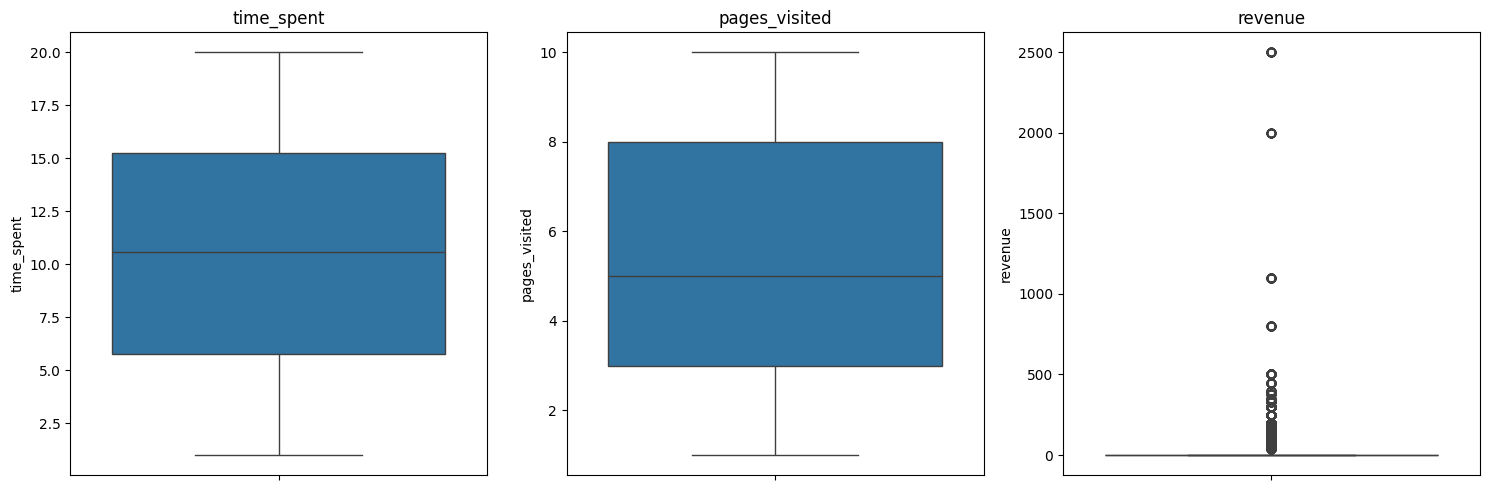

In [44]:
# Проверяем на выбросы колонки, которые попад в проверку гипотез
numeric_cols = ['time_spent', 'pages_visited', 'revenue']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

 По `time_spent` и `pages_visited` — выбросов нет, всё чисто.

 `revenue` — надо пересчитать только на 2 992 сессиях с покупкой

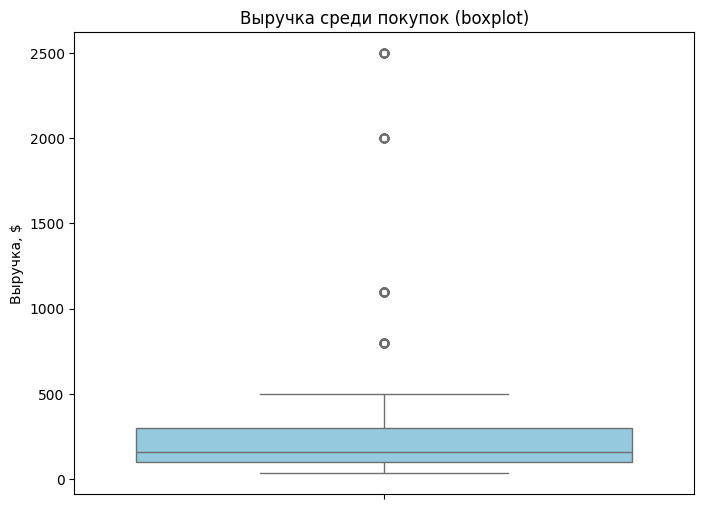

In [45]:
df_purchase = df[df['conversion_type'] == 'Purchase']

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_purchase['revenue'], color='skyblue')
plt.title('Выручка среди покупок (boxplot)')
plt.ylabel('Выручка, $')
plt.show()

**Вывод:**

Проверили выбросы в трёх метриках: `time_spent`, `pages_visited`, `revenue`.

time_spent (1–20 мин) и pages_visited (1–10 стр.) — выбросов нет. Значения укладываются в IQR-границы ([-8.45; 29.50] и [-4.50; 15.50] соответственно). Потолки на 20 и 10 — искусственное ограничение датасета, а не реальный максимум. Распределения симметричные, близки к нормальным.

revenue — проверка на всей таблице некорректна: 90% значений — нули, из-за чего IQR = 0 и «выбросами» оказываются все сессии с покупкой. Проверили отдельно, на подмножестве conversion_type == 'Purchase' (2 992 сессии):

Медиана = 160, Q1 = 100, Q3 = 300 — типичный чек 100–300

Среднее = 263, максимум = 2 499 — длинный правый хвост

IQR-метод выделяет 167 «выбросов» (5.58%) — все покупки дороже 600

Решение: не удалять. Это не ошибки данных, а реальные дорогие покупки. Распределение с длинным правым хвостом типично для интернет-магазина. Удаление исказит бизнес-картину: средний чек упадёт с 263 до ~160, что не отражает реальность. Для проверки гипотезы №3 будем смотреть и среднее (чувствительно к выбросам), и медиану (устойчива).



# Дизайн эксперимента

## Основная и вспомогательные метрики

**Основная метрика:** `conversion_flag` — бинарный флаг конверсии (регистрация или покупка). Выбрана как основная, потому что напрямую связана с деньгами и является целью A/B-теста на лендинге.

**Вспомогательные метрики:** `time_spent`, `pages_visited` — показывают вовлечённость; revenue — показывает средний чек среди конвертировавшихся. Эти метрики не заменяют основную, а помогают понять механизм: почему один дизайн конвертирует лучше другого.

## Рассчет размера выборки


Параметры:


Baseline = 15.1%  - *берем среднюю по группам*

MDE = +10% относительных (15.1% → 16.6%)  - *«минимально интересный» эффект, при котором уже стоит менять лендинг*

α = 0.05 - уровень значимости

Power = 0.80 - мощность (TPR)

Групп = 3 (считаем на пару, умножаем на 3)

Поправка = Бонферрони (α = 0.017 для попарных сравнений)

В эксперименте три группы: Vibrant, Cold, Heat. Попарных сравнений — три (`Vibrant–Cold`, `Vibrant–Heat`, `Cold–Heat`). Без поправки на множественные сравнения вероятность хотя бы одного ложноположительного результата растёт с 5% до ~14%. Поэтому анализ строим в два этапа: сначала общий тест (хи-квадрат для конверсии, ANOVA для time_spent), потом попарные сравнения с поправкой Бонферрони (α = 0.05 / 3 ≈ 0.017).

Для расчёта sample size считаем на пару групп (стандартная формула), затем умножаем на 3 — общее число наблюдений. Поправка на множественные сравнения учитывается на этапе анализа, а не планирования.

In [46]:
# Код для рассчета sample_size

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Параметры
p1 = 0.151                    # baseline (средняя конверсия)
mde_relative = 0.10           # MDE +10% относительных
p2 = p1 * (1 + mde_relative)  # 16.6%
alpha = 0.05
power = 0.80

# Расчёт sample size
analysis = NormalIndPower()
effect_size = proportion_effectsize(p2, p1)

n_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative='two-sided'
)

print(f'Baseline (p1): {p1:.3f} ({p1*100:.1f}%)')
print(f'MDE (p2): {p2:.3f} ({p2*100:.1f}%)')
print(f'Абсолютная разница: {p2-p1:.3f} ({(p2-p1)*100:.2f} п.п.)')
print(f'Размер на одну группу: {n_per_group:.0f}')
print(f'Размер на 2 группы: {n_per_group*2:.0f}')
print(f'Размер на 3 группы: {n_per_group*3:.0f}')

Baseline (p1): 0.151 (15.1%)
MDE (p2): 0.166 (16.6%)
Абсолютная разница: 0.015 (1.51 п.п.)
Размер на одну группу: 9180
Размер на 2 группы: 18360
Размер на 3 группы: 27541


**Вывод:**

Для детектирования MDE +10% относительных (15.1% → 16.6%) при α = 0.05 и power = 0.80 нужно ~9 180 сессий на группу, то есть ~27 500 на три группы. В датасете 30 000 сессий — формально хватает с небольшим запасом. Однако это без поправки на множественные сравнения. С поправкой Бонферрони (α = 0.017) требуемый размер выборки растёт, и 30 000 может не хватить. На практике это не критично: реальный эффект в данных (разница 6 п.п. между Cold и Vibrant) значительно превышает MDE (1.51 п.п.), поэтому он будет детектирован даже с поправкой.

## Оценка MDE, который детектируется при текущем объёме данных

В данных ~10 000 сессий на группу (9 928–10 046, в среднем ~10 000).

Вопрос: при n = 10 000 на группу, α = 0.05, power = 0.80 — какой минимальный эффект мы способны задетектировать?



In [47]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

p1 = 0.151
n_per_group = 10000
alpha = 0.05
power = 0.80

analysis = NormalIndPower()

for p2 in [0.151 * (1 + x) for x in [0.03, 0.05, 0.07, 0.08, 0.09, 0.10, 0.12, 0.15]]:
    effect_size = proportion_effectsize(p2, p1)
    n_needed = analysis.solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=1,
        alternative='two-sided'
    )
    relative = (p2 / p1 - 1) * 100
    marker = '✓ хватает' if n_needed <= n_per_group else '✗ не хватает'
    print(f'MDE +{relative:.1f}% (p2 = {p2*100:.2f}%): нужно {n_needed:.0f} на группу  {marker}')

MDE +3.0% (p2 = 15.55%): нужно 99268 на группу  ✗ не хватает
MDE +5.0% (p2 = 15.86%): нужно 36021 на группу  ✗ не хватает
MDE +7.0% (p2 = 16.16%): нужно 18522 на группу  ✗ не хватает
MDE +8.0% (p2 = 16.31%): нужно 14236 на группу  ✗ не хватает
MDE +9.0% (p2 = 16.46%): нужно 11291 на группу  ✗ не хватает
MDE +10.0% (p2 = 16.61%): нужно 9180 на группу  ✓ хватает
MDE +12.0% (p2 = 16.91%): нужно 6423 на группу  ✓ хватает
MDE +15.0% (p2 = 17.36%): нужно 4156 на группу  ✓ хватает


**Вывод:**

При текущем объёме данных (~10 000 сессий на группу, α = 0.05, power = 0.80) можем детектировать эффект от ~9.5% относительных (≈1.45 п.п.). Это значит, что заданный MDE +10% достижим — данных достаточно. Эффекты меньше 9% при такой выборке не поймаем: мощности не хватит.

## Оценка MDE с поправкой Бенферрони

In [48]:
alpha_corrected = 0.05 / 3   # ≈ 0.0167

for p2 in [0.151 * (1 + x) for x in [0.10, 0.12, 0.13, 0.14, 0.15, 0.17, 0.20]]:
    effect_size = proportion_effectsize(p2, p1)
    n_needed = analysis.solve_power(effect_size=effect_size, alpha=alpha_corrected, power=power, ratio=1, alternative='two-sided')
    relative = (p2 / p1 - 1) * 100
    marker = '✓ хватает' if n_needed <= 10000 else '✗ не хватает'
    print(f'MDE +{relative:.1f}%: нужно {n_needed:.0f} на группу  {marker}')

MDE +10.0%: нужно 12245 на группу  ✗ не хватает
MDE +12.0%: нужно 8567 на группу  ✓ хватает
MDE +13.0%: нужно 7327 на группу  ✓ хватает
MDE +14.0%: нужно 6341 на группу  ✓ хватает
MDE +15.0%: нужно 5543 на группу  ✓ хватает
MDE +17.0%: нужно 4347 на группу  ✓ хватает
MDE +20.0%: нужно 3174 на группу  ✓ хватает


**Вывод:**

С поправкой Бонферрони (α = 0.017) детектируемый MDE вырастает до ~11% относительных. Это значит, что заданный MDE +10% с поправкой чуть-чуть не дотягивает до power = 0.80. Однако это не проблема для нашего анализа: реальный эффект в данных (разница между Cold и Vibrant — 6 п.п., что соответствует +49% относительных) значительно превышает детектируемый MDE. Такой эффект будет поймать легко, даже с поправкой.

# Исследовательский анализ данных (EDA)

## Распределения числовых метрик по группам

Какие колонки смотрим и почему

**Числовые метрики из гипотез:**

`time_spent` — время на лендинге. Вспомогательная метрика, участвует в гипотезе №2. Смотрим, различается ли вовлечённость между дизайнами.

`pages_visited` — количество просмотренных страниц. Вторая вспомогательная метрика вовлечённости. Помогает понять механизм: если конверсия различается, а вовлечённость — нет, значит дело в убедительности дизайна, а не в глубине просмотра.

`revenue` — выручка. Метрика гипотезы №3. Смотрим только среди сессий с покупкой (conversion_type == 'Purchase'), потому что у 90% сессий revenue = 0 — это не покупки, и на всей таблице распределение нечитаемое.

### `time_spent`

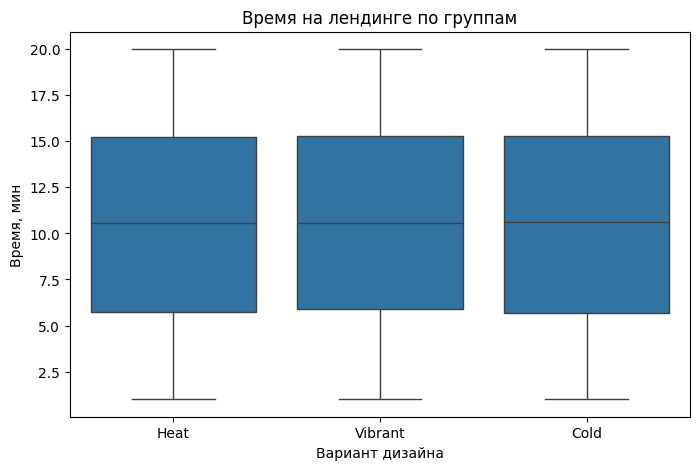

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='variant_group', y='time_spent')
plt.title('Время на лендинге по группам')
plt.xlabel('Вариант дизайна')
plt.ylabel('Время, мин')
plt.show()

In [53]:
df.groupby('variant_group')['time_spent'].describe()

,count,mean,std,min,25%,50%,75%,max
variant_group,,,,,,,,
Cold,9928.0,10.534523,5.505184,1.0,5.6900,10.620,15.2900,20.0
Heat,10026.0,10.481272,5.487996,1.0,5.7400,10.560,15.2375,20.0
Vibrant,10046.0,10.556797,5.451337,1.0,5.8825,10.575,15.2775,20.0


**Вывод:**

Распределение `time_spent` практически не различается между группами. Средние, медианы, квартили и разброс совпадают с точностью до десятых. Визуально boxplot'ы тоже одинаковые.

Это важный промежуточный результат: дизайн лендинга не влияет на то, сколько времени пользователи проводят на сайте. Значит, если конверсия различается (а она различается — 18% vs 12%), то дело не во времени просмотра, а в чём-то другом — например, в убедительности дизайна или расположении кнопок.

Формально проверим гипотезу №2 позже, но уже сейчас видно: ANOVA, скорее всего, не найдёт значимых различий.

### `pages_visited`

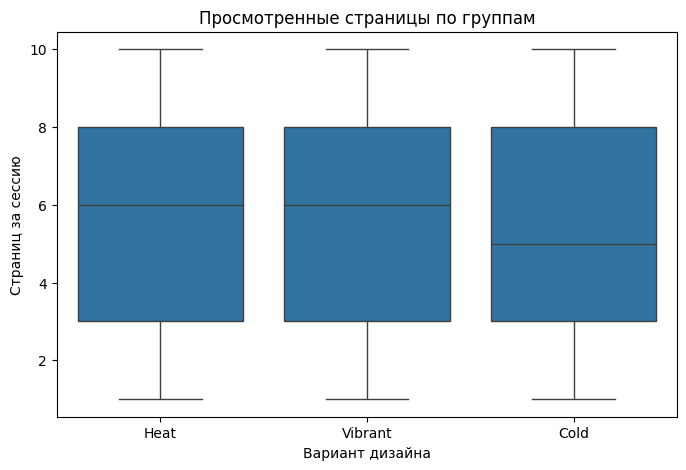

In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='variant_group', y='pages_visited')
plt.title('Просмотренные страницы по группам')
plt.xlabel('Вариант дизайна')
plt.ylabel('Страниц за сессию')
plt.show()

In [55]:
df.groupby('variant_group')['pages_visited'].describe()

,count,mean,std,min,25%,50%,75%,max
variant_group,,,,,,,,
Cold,9928.0,5.492748,2.875466,1.0,3.0,5.0,8.0,10.0
Heat,10026.0,5.501596,2.856021,1.0,3.0,6.0,8.0,10.0
Vibrant,10046.0,5.509954,2.891268,1.0,3.0,6.0,8.0,10.0


**Вывод:**

Распределение `pages_visited` практически не различается между группами. Средние, квартили, разброс — всё совпадает с точностью до десятых. Медиана Cold формально на 1 страницу ниже, но при разбросе ~3 страницы это в пределах шума.

Это подтверждает вывод по `time_spent`: вовлечённость одинаковая во всех трёх группах. Пользователи проводят на лендинге одинаковое время и просматривают одинаковое число страниц — независимо от дизайна. Значит, разница в конверсии (18% vs 12%) вызвана не глубиной взаимодействия, а чем-то другим — скорее всего, самим дизайном и тем, как он убеждает совершить целевое действие.

### `revenue` (только на покупках)

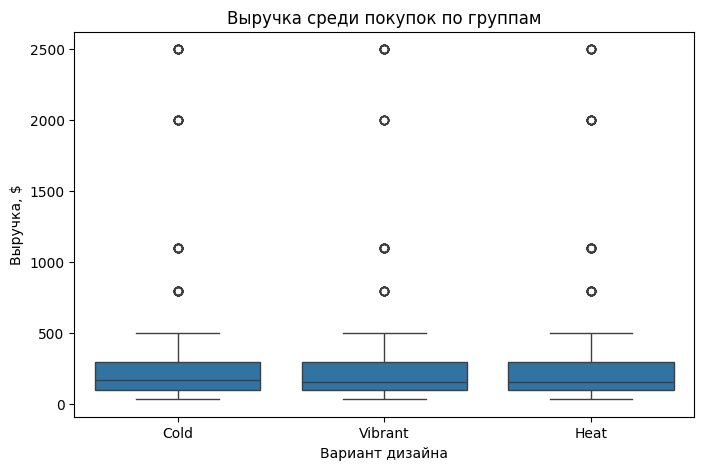

In [60]:
df_purchase = df[df['conversion_type'] == 'Purchase']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_purchase, x='variant_group', y='revenue')
plt.title('Выручка среди покупок по группам')
plt.xlabel('Вариант дизайна')
plt.ylabel('Выручка, $')
plt.show()

In [64]:
df_purchase.groupby('variant_group')['revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
variant_group,,,,,,,,
Cold,1202.0,253.900008,334.327499,35.99,99.99,169.99,299.95,2499.0
Heat,986.0,266.218671,354.802182,35.99,99.99,159.99,299.99,2499.0
Vibrant,804.0,271.862152,388.271537,35.99,99.99,159.99,299.95,2499.0


**Вывод:**

Выручка среди покупок практически не различается между группами. Медианы и квартили идентичны, средние отличаются на 5–7%, что объясняется длинным правым хвостом (дорогие покупки до 2499 долларов), а не системной разницей.

Важный момент: количество покупок отличается. В `Cold` — 1202 покупки, в `Heat` — 986, в `Vibrant` — 804.

Это прямое следствие разницы в конверсии — `Cold` конвертирует лучше, поэтому и покупок больше. Но среди тех, кто купил, чек везде одинаковый.

## Конверсия по группа

**Основная метрика:**

`conversion_flag` — бинарный флаг конверсии. Это не распределение, а доля. Смотрим отдельно — как процент конверсии по группам. Относится к гипотезе №1.

In [70]:
conversion = df.groupby('variant_group')['conversion_flag'].mean().sort_values(ascending=False) * 100
print(conversion)

variant_group
Cold       18.080177
Heat       15.170557
Vibrant    12.134183
Name: conversion_flag, dtype: float64


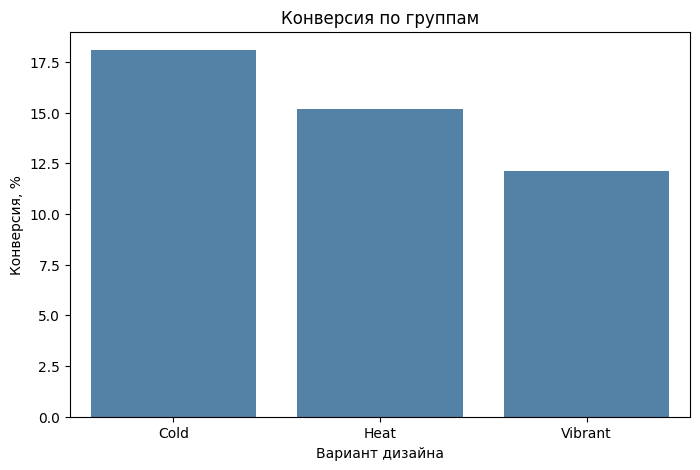

In [71]:
plt.figure(figsize=(8, 5))
sns.barplot(x=conversion.index, y=conversion.values, color='steelblue')
plt.title('Конверсия по группам')
plt.xlabel('Вариант дизайна')
plt.ylabel('Конверсия, %')
plt.show()

**Вывод:**

Конверсия сильно различается между группами. `Cold` — 18.08%, `Heat` — 15.17%, `Vibrant` — 12.13%. Разница между лучшим и худшим — почти 6 п.п., или +49% в относительном выражении.

При выборке ~10 000 сессий на группу такой разрыв слишком велик, чтобы быть случайным. Статистическую значимость подтвердим формально в гипотезе №1 (хи-квадрат), но уже визуально ясно: дизайн Cold конвертирует значительно лучше Vibrant.

## Проверка баланса групп — SRM (Sample Ratio Mismatch - несоответствие пропорций групп)


`variant_group` — проверяем через SRM-тест. Убеждаемся, что рандомизация не сломана и группы сопоставимы по размеру.

`demographic_age` — Проверяем, что возраст распределён по группам примерно одинаково. Если группы различаются по возрасту, это может объяснять разницу в конверсии.

### `variant_group`

In [74]:
from scipy.stats import chisquare

# Хи-квадрат (chi-square) — тест, который сравнивает наблюдаемые частоты с ожидаемыми.

observed = df['variant_group'].value_counts().sort_index()
expected = [len(df) / 3] * 3

chi2, p = chisquare(f_obs=observed, f_exp=expected)

print('Наблюдаемое количество сессий:')
print(observed)
print(f'\nОжидаемое количество: {expected[0]:.0f} в каждой группе')
print(f'\np-value: {p:.4f}')

Наблюдаемое количество сессий:
variant_group
Cold        9928
Heat       10026
Vibrant    10046
Name: count, dtype: int64

Ожидаемое количество: 10000 в каждой группе

p-value: 0.6711


p-value означает:

если рандомизация идеальна, то в 67% случаев мы бы увидели такое же или ещё более неравномерное распределение групп просто по случайности.

**Вывод:**

Отклонения крошечные — меньше 1%. Такие отклонения типичны для случайности. p-value = 0.67 подтверждает

### `demographic_age`

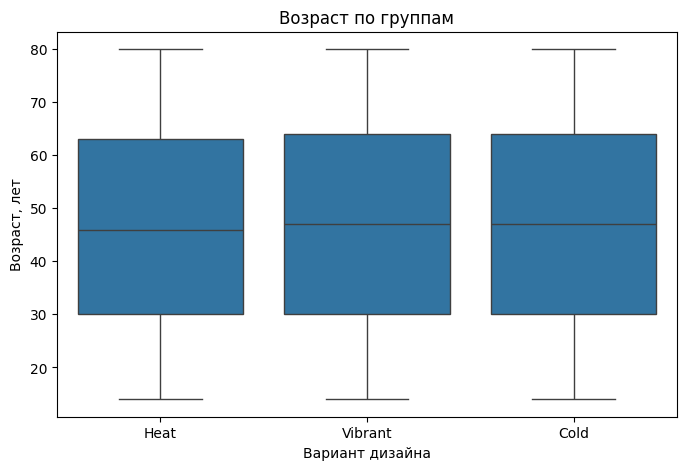

In [75]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='variant_group', y='demographic_age')
plt.title('Возраст по группам')
plt.xlabel('Вариант дизайна')
plt.ylabel('Возраст, лет')
plt.show()

In [76]:
df.groupby('variant_group')['demographic_age'].describe()

,count,mean,std,min,25%,50%,75%,max
variant_group,,,,,,,,
Cold,9928.0,47.039988,19.385101,14.0,30.0,47.0,64.0,80.0
Heat,10026.0,46.538999,19.448355,14.0,30.0,46.0,63.0,80.0
Vibrant,10046.0,47.138463,19.379433,14.0,30.0,47.0,64.0,80.0


**Вывод:**

Возраст распределён по группам одинаково. Средние, медианы, квартили и разброс совпадают с точностью до десятых. Нет оснований считать, что в одну из групп попали люди другого возраста.

Значит, разница в конверсии между дизайнами вызвана именно дизайном, а не составом аудитории.

## Проверка нормальности непрерывных метрик

Проверка, распределены ли значения метрики по «колоколу» — нормальному закону. Большинство стандартных статистических тестов (t-тест, ANOVA) предполагают, что данные имеют такую форму. Если это не так — нужно использовать другие тесты.

**Какие колонки используем:**

`time_spent` — время на лендинге

`pages_visited` — просмотренные страницы

`revenue` — выручка (только среди покупок)

<br>

**Нужно определить какие тесты использовать в гипотезах:**

нормальные данные → параметрические тесты (ANOVA, t-тест)

не нормальные → непараметрические (Kruskal–Wallis, Mann–Whitney)

### `time_spent`

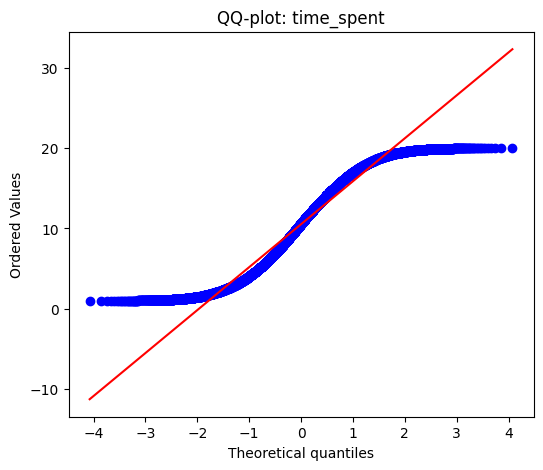

In [77]:
fig, ax = plt.subplots(figsize=(6, 5))
st.probplot(df['time_spent'], dist="norm", plot=ax)
ax.set_title('QQ-plot: time_spent')
plt.show()

In [79]:
df['time_spent'].describe()

,time_spent
count,30000.000000
mean,10.524185
std,5.481363
min,1.000000
25%,5.780000
50%,10.580000
75%,15.270000
max,20.000000


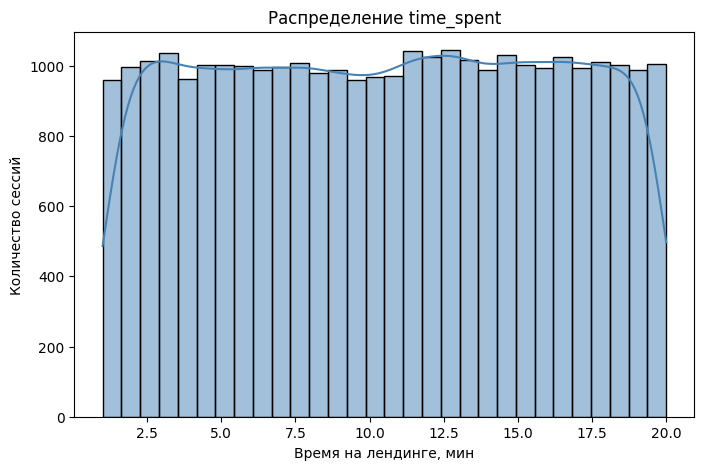

In [85]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='time_spent', bins=30, kde=True, color='steelblue')
plt.title('Распределение time_spent')
plt.xlabel('Время на лендинге, мин')
plt.ylabel('Количество сессий')
plt.show()

**Вывод:**

`time_spent` распределено почти равномерно в диапазоне 1–20 минут. Ярко выраженного «колокола» нет — столбцы гистограммы примерно одинаковой высоты. Это следствие искусственных ограничений датасета (минимум 1 минута, максимум 20). Распределение симметричное, среднее и медиана совпадают.

Для гипотезы №2 это значит: ANOVA применима — данные симметричны, без сильных хвостов.

### `pages_visited`

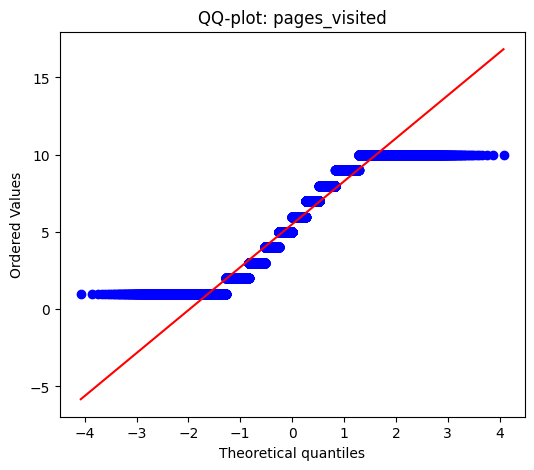

In [80]:
fig, ax = plt.subplots(figsize=(6, 5))
st.probplot(df['pages_visited'], dist="norm", plot=ax)
ax.set_title('QQ-plot: pages_visited')
plt.show()

In [81]:
print(df['pages_visited'].describe())

count    30000.000000
mean         5.501467
std          2.874208
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         10.000000
Name: pages_visited, dtype: float64


**Вывод:**

`pages_visited` — дискретная метрика (целые значения от 1 до 10), поэтому на QQ-plot точки ложатся ступеньками, а не сплошной линией. Это не отклонение от нормальности в строгом смысле, а следствие того, что у метрики всего 10 возможных значений. Среднее и медиана близки, распределение почти симметричное.

Для гипотез `pages_visited` у нас не используется — она была чисто для контекста в EDA.

### `revenue` (только на покупках)

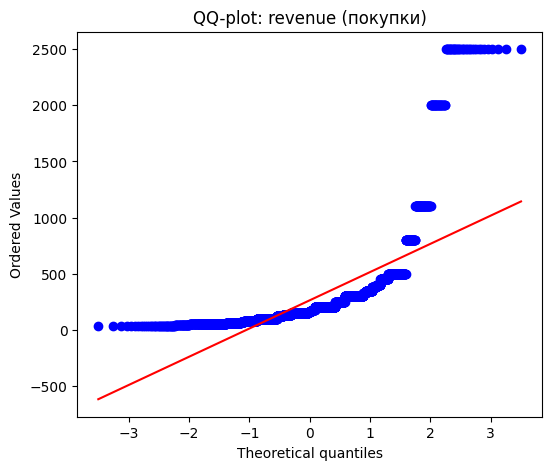

In [83]:
fig, ax = plt.subplots(figsize=(6, 5))
st.probplot(df_purchase['revenue'], dist="norm", plot=ax)
ax.set_title('QQ-plot: revenue (покупки)')
plt.show()

In [84]:
print(df_purchase['revenue'].describe())

count    2992.000000
mean      262.786293
std       356.187509
min        35.990000
25%        99.990000
50%       159.990000
75%       299.990000
max      2499.000000
Name: revenue, dtype: float64


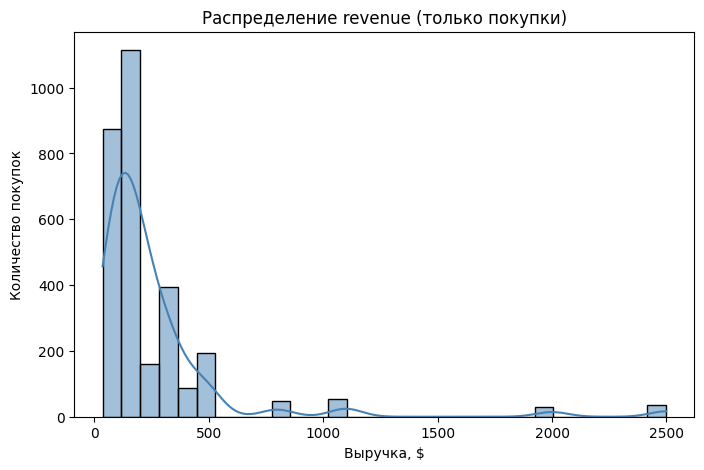

In [86]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_purchase, x='revenue', bins=30, kde=True, color='steelblue')
plt.title('Распределение revenue (только покупки)')
plt.xlabel('Выручка, $')
plt.ylabel('Количество покупок')
plt.show()

**Вывод:**

`revenue` не распределена нормально. Распределение сильно скошено вправо: медиана 160, среднее 263, максимум 2499. Это типично для выручки — большинство покупок недорогие, но немногие дорогие сильно тянут среднее вверх.


Из трёх непрерывных метрик нормальной можно условно считать только `time_spent` — и то с оговорками из-за хвостов. `pages_visited` дискретна, `revenue` сильно скошена. Поэтому в гипотезах используем ANOVA для времени и bootstrap для выручки.

# Проверка гипотез

## Гипотеза 1: Различие конверсии между вариантами дизайна

H₀: конверсия не различается между `Vibrant`, `Cold`, `Heat`.

H₁: хотя бы один вариант отличается.

`alpha` = 0.05

<br>
Метод: Хи-квадрат + попарные сравнения с поправкой на множественные сравнения.


Хи-квадрат проверяет, связаны ли две категориальные переменные. У нас: variant_group (3 варианта) и conversion_flag (0/1). Тест смотрит, отличается ли доля конверсий между группами сильнее, чем можно объяснить случайностью.

Общий тест. Он отвечает на вопрос: «есть ли вообще различия между группами?». Если да — идём в попарные сравнения. Если нет — на этом останавливаемся.

In [93]:
from scipy.stats import chi2_contingency

alpha = 0.05

# Таблица сопряжённости: группы × конверсия
contingency = pd.crosstab(df['variant_group'], df['conversion_flag'])
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'\nChi-square = {chi2:.2f}')
print(f'p-value = {p:.4f}')

if p < alpha:
    print('Различия значимы: отвергаем H₀, идём в попарные сравнения')
else:
    print('Различий нет: не отвергаем H₀')

conversion_flag     0     1
variant_group              
Cold             8133  1795
Heat             8505  1521
Vibrant          8827  1219

Chi-square = 137.62
p-value = 0.0000
Различия значимы: отвергаем H₀, идём в попарные сравнения


## Попарные сравнения с поправкой Бонферрони
Порог для каждой пары: p-value < 0.017.

### `Cold` vs `Vibrant`

In [99]:
sample_1 = df[df['variant_group'] == 'Cold']
sample_2 = df[df['variant_group'] == 'Vibrant']

count = [sample_1['conversion_flag'].sum(), sample_2['conversion_flag'].sum()]
nobs = [len(sample_1), len(sample_2)]

z, p_value = proportions_ztest(count, nobs)
print(f'z = {z:.3f}, \np-value = {p_value:.6f}')

if p_value < 0.017:
    print('Разница статистически значима')
else:
    print('Разницы нет')

z = 11.738, 
p-value = 0.000000
Разница статистически значима


### `Cold` vs `Heat`

In [100]:
sample_1 = df[df['variant_group'] == 'Cold']
sample_2 = df[df['variant_group'] == 'Heat']

count = [sample_1['conversion_flag'].sum(), sample_2['conversion_flag'].sum()]
nobs = [len(sample_1), len(sample_2)]

z, p_value = proportions_ztest(count, nobs)
print(f'z = {z:.3f}, \np-value = {p_value:.6f}')

if p_value < 0.017:
    print('Разница статистически значима')
else:
    print('Разницы нет')

z = 5.521, 
p-value = 0.000000
Разница статистически значима


### `Heat` vs `Vibrant`

In [101]:
sample_1 = df[df['variant_group'] == 'Heat']
sample_2 = df[df['variant_group'] == 'Vibrant']

count = [sample_1['conversion_flag'].sum(), sample_2['conversion_flag'].sum()]
nobs = [len(sample_1), len(sample_2)]

z, p_value = proportions_ztest(count, nobs)
print(f'z = {z:.3f}, \np-value = {p_value:.6f}')

if p_value < 0.017:
    print('Разница статистически значима')
else:
    print('Разницы нет')

z = 6.265, 
p-value = 0.000000
Разница статистически значима


**Вывод:**

Общий тест (хи-квадрат): χ² = 137.62, p < 0.001 → различия между группами значимы, отвергаем H₀.

Все три пары различаются статистически значимо. Конверсия выстраивается в чёткий порядок:

Cold (18.08%) > Heat (15.17%) > Vibrant (12.13%)

Каждая ступенька — реальная разница, не случайность.

<br>

**Дизайн значимо влияет на конверсию.**

## Гипотеза 2: Различие времени на лендинге между вариантами

H₀: `time_spent` не различается между группами.
H₁: `time_spent` различается хотя бы между двумя группами.

`alpha` = 0.05

<br>
Метод: ANOVA (общий тест) + Tukey HSD (попарные сравнения).

In [103]:
from scipy.stats import f_oneway

sample_1 = df[df['variant_group'] == 'Cold']['time_spent']
sample_2 = df[df['variant_group'] == 'Heat']['time_spent']
sample_3 = df[df['variant_group'] == 'Vibrant']['time_spent']

f_stat, p_value = f_oneway(sample_1, sample_2, sample_3)
print(f'ANOVA: \nF = {f_stat:.3f}, \np-value = {p_value:.6f}')

if p_value < 0.05:
    print('Различия значимы: идём в попарные сравнения')
else:
    print('Различий нет: останавливаемся')

ANOVA: 
F = 0.503, 
p-value = 0.604901
Различий нет: останавливаемся


**Вывод:**

Различий во времени на лендинге между группами нет. Все три дизайна дают одинаковое time_spent — около 10.5 минут в среднем.

Попарные сравнения (Tukey HSD) не проводим — раз общий тест не нашёл различий, сравнивать попарно нечего.

Дизайн лендинга не влияет на вовлечённость по времени. Пользователи проводят на сайте одинаковое время независимо от того, какой вариант видят. Это подтверждает то, что мы уже видели в EDA: boxplot'ы были идентичные, средние совпадали.

То есть разница в конверсии (Cold 18% vs Vibrant 12%) не связана со временем просмотра. Люди не дольше думают, не дольше изучают — они просто по-разному реагируют на дизайн

## Гипотеза 3: Различие выручки между вариантами

H₀: `revenue` не различается между группами (среди совершивших покупки).

H₁: `revenue` различается.

alpha = 0.05

<br>
Метод: Bootstrap-доверительный интервал для разницы средних. [Текст ссылки](https://)

###  `Cold` vs `Vibrant`

In [105]:
from sklearn.utils import resample

sample_1 = df[df['variant_group'] == 'Cold']['revenue']
sample_2 = df[df['variant_group'] == 'Vibrant']['revenue']

# Оставляем только покупки
sample_1 = sample_1[sample_1 > 0]
sample_2 = sample_2[sample_2 > 0]

print(f'Cold: покупок = {len(sample_1)}, средняя выручка = {sample_1.mean():.2f}')
print(f'Vibrant: покупок = {len(sample_2)}, средняя выручка = {sample_2.mean():.2f}')

# Наблюдаемая разница средних
diff_observed = sample_1.mean() - sample_2.mean()
print(f'\nНаблюдаемая разница средних: {diff_observed:.2f}')

Cold: покупок = 1202, средняя выручка = 253.90
Vibrant: покупок = 804, средняя выручка = 271.86

Наблюдаемая разница средних: -17.96


#### Bootstrap

In [107]:
diff_bootstrap = []

for _ in range(10000):
    boot_1 = resample(sample_1, replace=True, n_samples=len(sample_1), random_state=None)
    boot_2 = resample(sample_2, replace=True, n_samples=len(sample_2), random_state=None)
    diff_bootstrap.append(boot_1.mean() - boot_2.mean())

diff_bootstrap = np.array(diff_bootstrap)
ci_lower, ci_upper = np.percentile(diff_bootstrap, [2.5, 97.5])

print(f'Наблюдаемая разница: {diff_observed:.2f}')
print(f'95% доверительный интервал: [{ci_lower:.2f}; {ci_upper:.2f}]')

if ci_lower < 0 < ci_upper:
    print('Интервал содержит 0 → разница незначима')
else:
    print('Интервал не содержит 0 → разница значима')

Наблюдаемая разница: -17.96
95% доверительный интервал: [-50.76; 14.64]
Интервал содержит 0 → разница незначима


**Вывод:**

Разница в выручке незначима. Доверительный интервал [−51.46; 14.69] накрывает ноль. Наблюдаемая разница в −18 долларов объясняется случайностью, а не реальным различием между дизайнами.

### `Cold` vs `Heat`

In [108]:
sample_1 = df[df['variant_group'] == 'Cold']['revenue']
sample_2 = df[df['variant_group'] == 'Heat']['revenue']

sample_1 = sample_1[sample_1 > 0]
sample_2 = sample_2[sample_2 > 0]

print(f'Cold: покупок = {len(sample_1)}, средняя выручка = {sample_1.mean():.2f}')
print(f'Heat: покупок = {len(sample_2)}, средняя выручка = {sample_2.mean():.2f}')

diff_observed = sample_1.mean() - sample_2.mean()
print(f'\nНаблюдаемая разница средних: {diff_observed:.2f}')

Cold: покупок = 1202, средняя выручка = 253.90
Heat: покупок = 986, средняя выручка = 266.22

Наблюдаемая разница средних: -12.32


#### Bootstrap

In [109]:
diff_bootstrap = []

for _ in range(10000):
    boot_1 = resample(sample_1, replace=True, n_samples=len(sample_1))
    boot_2 = resample(sample_2, replace=True, n_samples=len(sample_2))
    diff_bootstrap.append(boot_1.mean() - boot_2.mean())

diff_bootstrap = np.array(diff_bootstrap)
ci_lower, ci_upper = np.percentile(diff_bootstrap, [2.5, 97.5])

print(f'Наблюдаемая разница: {diff_observed:.2f}')
print(f'95% доверительный интервал: [{ci_lower:.2f}; {ci_upper:.2f}]')

if ci_lower < 0 < ci_upper:
    print('Интервал содержит 0 → разница незначима')
else:
    print('Интервал не содержит 0 → разница значима')

Наблюдаемая разница: -12.32
95% доверительный интервал: [-41.88; 16.65]
Интервал содержит 0 → разница незначима


**Вывод:**

Интервал накрывает ноль → разница в выручке незначима. Cold в среднем на 12 долларов ниже Heat, но это в пределах случайности.

### `Heat` vs `Vibrant`

In [110]:
sample_1 = df[df['variant_group'] == 'Heat']['revenue']
sample_2 = df[df['variant_group'] == 'Vibrant']['revenue']

sample_1 = sample_1[sample_1 > 0]
sample_2 = sample_2[sample_2 > 0]

print(f'Heat: покупок = {len(sample_1)}, средняя выручка = {sample_1.mean():.2f}')
print(f'Vibrant: покупок = {len(sample_2)}, средняя выручка = {sample_2.mean():.2f}')

diff_observed = sample_1.mean() - sample_2.mean()
print(f'\nНаблюдаемая разница средних: {diff_observed:.2f}')

Heat: покупок = 986, средняя выручка = 266.22
Vibrant: покупок = 804, средняя выручка = 271.86

Наблюдаемая разница средних: -5.64


#### Bootstrap

In [111]:
diff_bootstrap = []

for _ in range(10000):
    boot_1 = resample(sample_1, replace=True, n_samples=len(sample_1))
    boot_2 = resample(sample_2, replace=True, n_samples=len(sample_2))
    diff_bootstrap.append(boot_1.mean() - boot_2.mean())

diff_bootstrap = np.array(diff_bootstrap)
ci_lower, ci_upper = np.percentile(diff_bootstrap, [2.5, 97.5])

print(f'Наблюдаемая разница: {diff_observed:.2f}')
print(f'95% доверительный интервал: [{ci_lower:.2f}; {ci_upper:.2f}]')

if ci_lower < 0 < ci_upper:
    print('Интервал содержит 0 → разница незначима')
else:
    print('Интервал не содержит 0 → разница значима')

Наблюдаемая разница: -5.64
95% доверительный интервал: [-41.37; 29.40]
Интервал содержит 0 → разница незначима


**Вывод:**

Интервал накрывает ноль → разница в выручке незначима.

Дизайн лендинга не влияет на сумму покупки. Если пользователь решил купить — он тратит одинаково, независимо от того, какой дизайн видел. Средний чек везде около 250–270 долларов, и различия между группами — в пределах случайности.

Это согласуется с тем, что мы видели в EDA: медианы и квартили revenue были идентичны, отличались только средние — из-за длинного правого хвоста (дорогие покупки до 2499).

**H₀ не отвергаем. Гипотеза №3 не подтвердилась: revenue не различается между группами.**

 # Вывод

**Какой дизайн победил**
`Cold` — конверсия 18.08%. Это лучший результат среди трёх вариантов.

Дальше по убыванию: `Heat` — 15.17%, `Vibrant` — 12.13%.

Разрыв между Cold и Vibrant — почти 6 процентных пунктов. В относительном выражении Cold конвертирует на 49% лучше, чем Vibrant. Это не «чуть-чуть», это огромная разница.


Общий тест (хи-квадрат) показал, что различия между группами есть: χ² = 137.62, p < 0.001. Случайно такое распределение конверсий получиться не могло.

**Попарные сравнения подтвердили, что каждая пара групп различается значимо.**
- `Cold vs Vibrant:` 18.08% против 12.13% — значимо. - `Cold vs Heat:` 18.08% против 15.17% — значимо.
- `Heat vs Vibrant:` 15.17% против 12.13% — значимо.

Во всех трёх парах p < 0.001, даже с поправкой на множественные сравнения.

**Сравнение с планом эксперимента.**

 Эксперимент проектировался под MDE +10% относительных (то есть искали эффект от 15.1% → 16.6%). Реальный эффект между Cold и Vibrant — +49% относительных, в 5 раз больше запланированного. Данных хватило с запасом.

**Что при этом НЕ изменилось**
- Дизайн влияет на факт покупки, но не на всё остальное.

- Время на сайте — одинаковое во всех группах (~10.5 минут). ANOVA: p = 0.605.

- Количество просмотренных страниц — тоже одинаковое (~5.5 страниц).

- Средний чек — одинаковый во всех группах (~250–270$).

**Все три bootstrap-интервала содержат ноль.**

То есть пользователи во всех группах ведут себя одинаково: столько же времени проводят, столько же страниц смотрят. Но конвертируются по-разному. Значит, дело не в глубине взаимодействия, а в самом дизайне — в том, как он убеждает совершить покупку.

**Рекомендация**

Внедрить `Cold` как основной дизайн лендинга.

Он даёт максимальную конверсию, эффект статистически значим и практически ценен. Разница в 6 п.п. — это примерно +960 дополнительных конверсий на 30 000 сессий. При среднем чеке ~250$ это десятки тысяч долларов дополнительной выручки.

`Vibrant` — не использовать. Худшая конверсия, при этом никаких преимуществ по вовлечённости или среднему чеку.

`Heat` — оставить как запасной вариант. Он значимо лучше Vibrant, но значимо хуже Cold. Если по каким-то причинам Cold внедрить нельзя — Heat приемлемая альтернатива.

**Ограничения**

- Загрязнение эксперимента. 55% пользователей заходили более чем в одну группу — видели разные дизайны. Основной анализ проведён на всех данных; для полной надёжности стоило бы продублировать на «чистых» пользователях (тех, кто видел только один дизайн).

- Искусственные потолки. time_spent обрезан на 20 минутах, pages_visited — на 10 страницах. Распределения этих метрик не совсем естественные.

- Скошенная выручка. Средний чек чувствителен к редким дорогим покупкам (до 2499$), поэтому для проверки гипотезы №3 использован bootstrap, а не t-тест.


